# Name: Ananta Gurung
# ID: 2414247



In [17]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report

# Task 1: Data Understanding and Visualization:

In [18]:
# Get the list of class directories from the train folder.

DATASET_DIR = "/content/drive/MyDrive/AI and ML/week 5/FruitinAmazon"

train_dir = os.path.join(DATASET_DIR, "train")
test_dir = os.path.join(DATASET_DIR, "test")

# List classes
classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
num_classes = len(classes)
print(f"\nClasses ({num_classes}): {classes}")

# Count images per class
for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    count = len([f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))])
    print(f"  {cls}: {count} images")


Classes (6): ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
  acai: 15 images
  cupuacu: 15 images
  graviola: 15 images
  guarana: 15 images
  pupunha: 15 images
  tucuma: 15 images


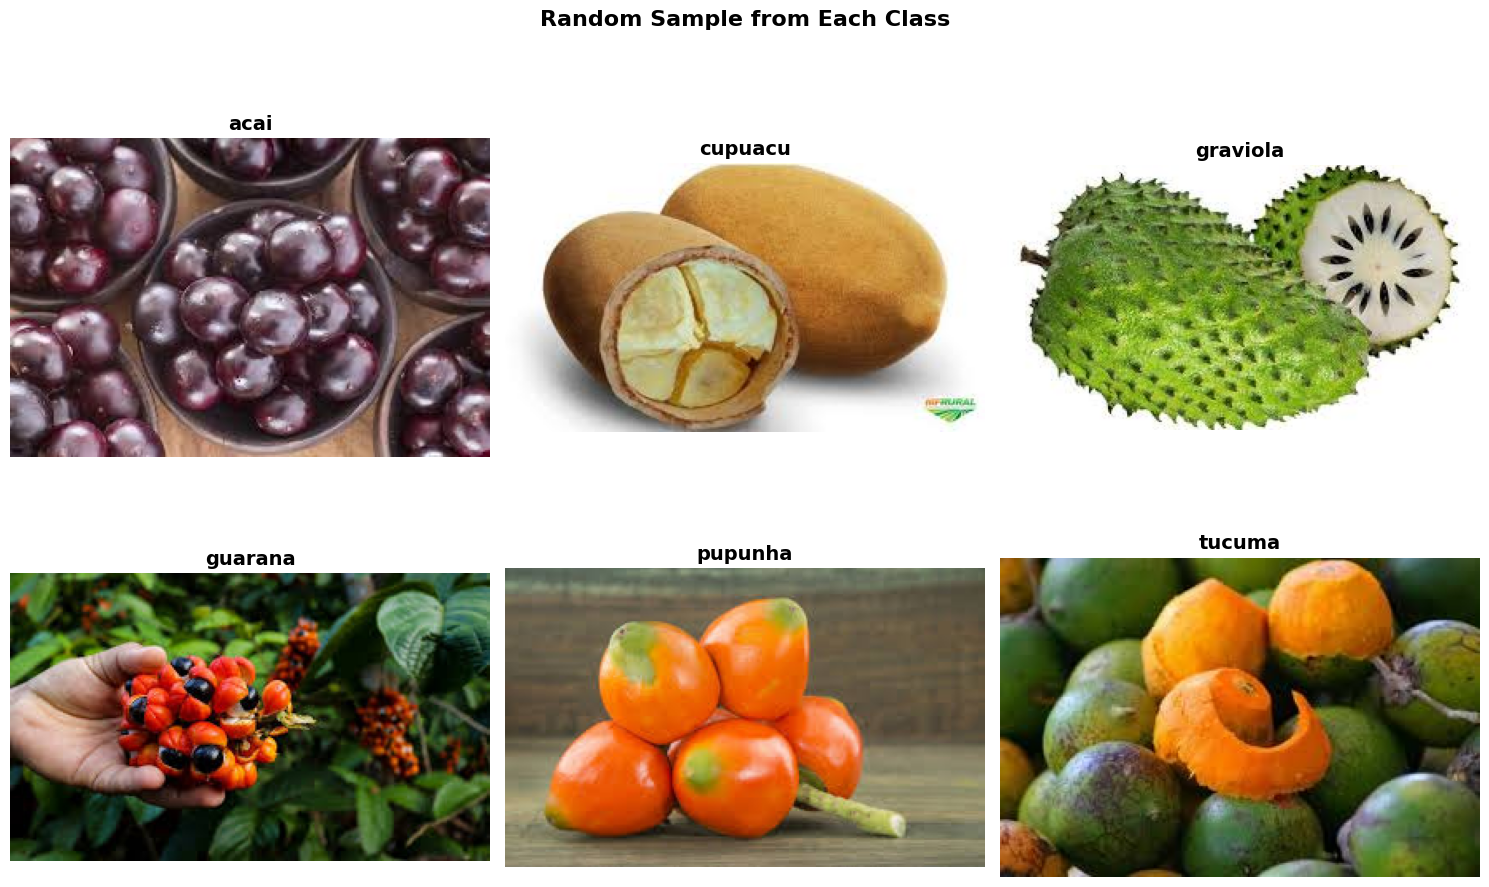

In [19]:
# Select one random image from each class and display in a grid
n_classes = len(classes)
cols = min(3, n_classes)
rows = (n_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
if rows == 1 and cols == 1:
    axes = np.array([axes])
axes = axes.flatten()

for idx, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    img_files = [f for f in os.listdir(cls_path) if os.path.isfile(os.path.join(cls_path, f))]
    random_img = random.choice(img_files)
    img_path = os.path.join(cls_path, random_img)

    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(cls, fontsize=14, fontweight='bold')
    axes[idx].axis('off')

# Hide unused subplots
for idx in range(n_classes, len(axes)):
    axes[idx].axis('off')

plt.suptitle("Random Sample from Each Class", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**2. Check for Corrupted Image:**

In [20]:


DATASET_DIR = "/content/drive/MyDrive/AI and ML/week 5/FruitinAmazon"
train_dir = os.path.join(DATASET_DIR, "train")

corrupted_images = []

# Iterate through each class folder
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    # Iterate through each image in the class folder
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            with Image.open(img_path) as img:
                img.verify()  # verify image integrity

        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

# Final output
if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


# Task 2: Loading and Preprocessing Image Data in keras:

In [21]:
# Define image size and batch size
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Create a preprocessing layer for normalization

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels="inferred",
  label_mode="int",
  image_size=(img_height, img_width),
  interpolation="nearest",
  batch_size=batch_size,
  shuffle=True,
  validation_split=validation_split,
  subset="training",
  seed=123
)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels="inferred",
  label_mode="int",
  image_size=(img_height, img_width),
  interpolation="nearest",
  batch_size=batch_size,
  shuffle=False,
  validation_split=validation_split,
  subset="validation",
  seed=123
)

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Prefetch for performance
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


# Task 3 - Implement a CNN

In [22]:
model = Sequential([
    # Convolutional Layer 1
    Conv2D(32, (3, 3), activation='relu', padding='same', strides=1,
           input_shape=(img_height, img_width, 3)),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    # Convolutional Layer 2
    Conv2D(32, (3, 3), activation='relu', padding='same', strides=1),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    # Fully Connected Layers
    Flatten(),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),

    # Output Layer
    Dense(num_classes, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4: Compile the Model

In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully.")

Model compiled successfully.


# Train the Model

In [24]:
# Callbacks
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train
history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.1453 - loss: 1.8527


Epoch 1: val_accuracy improved from None to 0.66667, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 809ms/step - accuracy: 0.1389 - loss: 1.8721 - val_accuracy: 0.6667 - val_loss: 1.5222
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.4097 - loss: 1.6084
Epoch 2: val_accuracy did not improve from 0.66667
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 732ms/step - accuracy: 0.4167 - loss: 1.5864 - val_accuracy: 0.6667 - val_loss: 1.2587
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.3530 - loss: 1.3502
Epoch 3: val_accuracy did not improve from 0.66667
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 459ms/step - accuracy: 0.4028 - loss: 1.2982 - val_accuracy: 0.6667 - val_loss: 1.1393
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.5532 - loss: 1.0665
Epoch 4: val_accuracy did not improve from 0.66667
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 519ms/step - accuracy: 0.5972 - loss: 1.0180 - val_accuracy: 0.6667 - val_loss: 0.9525
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.8709 - loss: 0.689


Epoch 6: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 501ms/step - accuracy: 0.7083 - loss: 0.6748 - val_accuracy: 0.7778 - val_loss: 0.9649
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.8409 - loss: 0.4041
Epoch 7: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 485ms/step - accuracy: 0.8194 - loss: 0.4302 - val_accuracy: 0.7778 - val_loss: 0.7814
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.9190 - loss: 0.3126
Epoch 8: val_accuracy improved from 0.77778 to 0.83333, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 844ms/step - accuracy: 0.9444 - loss: 0.2707 - val_accuracy: 0.8333 - val_loss: 0.5669
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.9797 - loss: 0.2089
Epoch 9: val_accuracy improved from 0.83333 to 0.88889, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 510ms/step - accuracy: 0.9861 - loss: 0.2072 - val_accuracy: 0.8889 - val_loss: 0.3635
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 1.0000 - loss: 0.0805
Epoch 10: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 515ms/step - accuracy: 1.0000 - loss: 0.0761 - val_accuracy: 0.8333 - val_loss: 0.5662
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 1.0000 - loss: 0.0711
Epoch 11: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 471ms/step - accuracy: 1.0000 - loss: 0.0686 - val_accuracy: 0.8333 - val_loss: 0.6679
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 1.0000 - loss: 0.0393
Epoch 12: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 535ms/step - accuracy: 1.0000 - loss: 0.0372 - val_accuracy: 0.8333 - val_loss: 0.4708
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 1.0000 - loss

# Task 5: Evaluate the Model

In [25]:
if test_dir and os.path.isdir(test_dir):
    test_ds = tf.keras.preprocessing.image_dataset_from_directory(
        test_dir,
        labels='inferred',
        label_mode='int',
        image_size=(img_height, img_width),
        interpolation='nearest',
        batch_size=batch_size,
        shuffle=False
    )
    test_ds = test_ds.map(lambda x, y: (rescale(x), y))
    test_ds = test_ds.prefetch(tf.data.AUTOTUNE)
    print("Separate test dataset loaded.")
else:
    # Use validation set as test set
    test_ds = val_ds
    print("No separate test directory — using validation set for evaluation.")

# Evaluate
test_loss, test_acc = model.evaluate(test_ds)

print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")



Found 30 files belonging to 6 classes.
Separate test dataset loaded.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 472ms/step - accuracy: 0.7000 - loss: 0.9859

Test Loss:     0.9859
Test Accuracy: 0.7000


**Visualization**

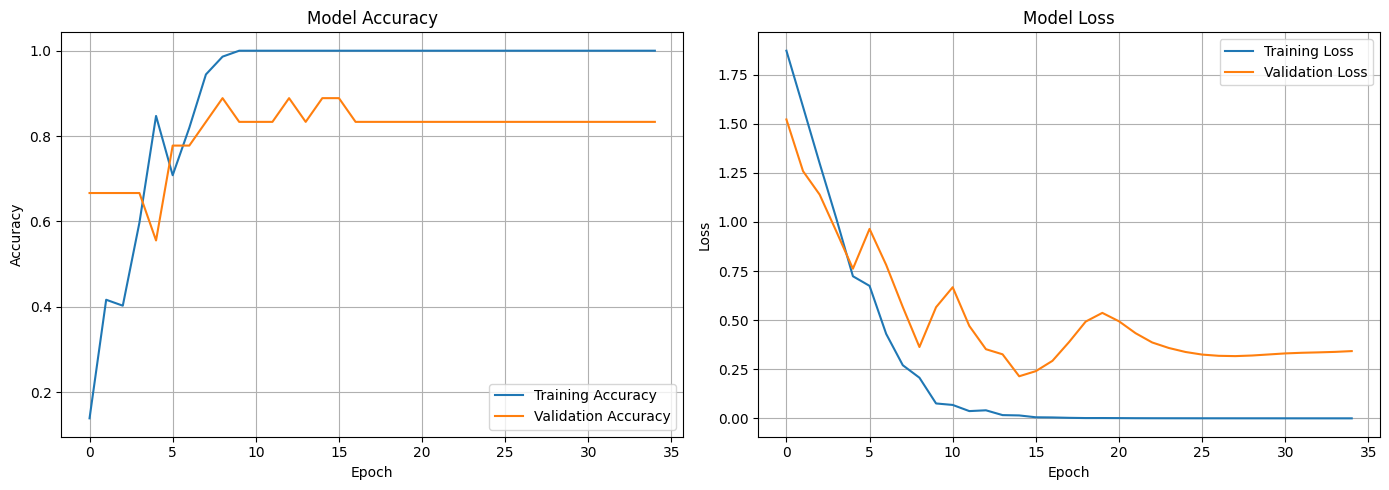

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

**Classification Report**

In [27]:
# Collect all predictions and true labels from the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification Report
print("Classification Report")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=classes))

Classification Report
              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
     cupuacu       0.50      0.60      0.55         5
    graviola       0.71      1.00      0.83         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.83      1.00      0.91         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.70        30
   macro avg       0.73      0.70      0.68        30
weighted avg       0.73      0.70      0.68        30



**Saved Model**

In [28]:
# Save
model.save('fruit_image_classifier_cnn.h5')
print("Model saved to 'fruit_image_classifier_cnn.h5'")

# Load
loaded_model = tf.keras.models.load_model('fruit_image_classifier_cnn.h5')
print("Model loaded successfully.")

# Re-evaluate loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print(f"\nLoaded Model — Test Loss:     {loaded_loss:.4f}")
print(f"Loaded Model — Test Accuracy: {loaded_acc:.4f}")

Model saved to 'fruit_image_classifier_cnn.h5'


Model loaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step - accuracy: 0.7000 - loss: 0.9859

Loaded Model — Test Loss:     0.9859
Loaded Model — Test Accuracy: 0.7000
